**Nom du fichier :** Semoune_Notebook_PredictBoost_V2.0
**Version :** V2.0
**Créé par :** Naima Bouchahdane-Semoune
**Date :** Avril 2026

## **1. Contexte métier**

Les équipes marketing e-commerce pilotent des campagnes de recommandation multicanales (email, push, notifications) destinées à augmenter la conversion, le panier moyen et la fidélisation des clients.

Ces campagnes s'appuient sur des volumes importants de données comportementales hétérogènes, issues de la navigation, de l'historique d'achats et des interactions avec les dispositifs marketing.

Dans ce contexte, les équipes doivent arbitrer finement entre la rentabilité des campagnes (ROI), la maîtrise de la pression marketing exercée sur les clients et le respect strict des réglementations internationales en matière de protection des données personnelles.

## **2. Problématique**

Comment assister les équipes marketing dans l'arbitrage de campagnes de recommandation complexes, basées sur des données comportementales hétérogènes et volumineuses, tout en garantissant la rentabilité (ROI), l'explicabilité des décisions et la conformité stricte aux réglementations internationales sur les données personnelles ?

## **3. Objectif de la solution IA**

- Fournir un score d'aide à la décision marketing
- Permettre un arbitrage ROI / pression commerciale
- Garantir explicabilité et conformité by design

## **4. Périmètre du livrable**

- Solution IA de recommandation
- Notebook démontrant conception et implémentation
- Logique exploitable par des équipes marketing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Description des données**

Les données utilisées dans ce projet sont des données comportementales issues d'un contexte e-commerce. Elles décrivent les interactions des utilisateurs avec les dispositifs marketing et le site marchand, sans contenir d'identifiants directs.

Le jeu de données comprend notamment :
- des informations de navigation et d'engagement (visites récentes, catégories consultées),
- des informations transactionnelles agrégées (panier moyen, montants dépensés),
- des informations liées aux campagnes marketing (canal d'acquisition, clic sur recommandation),
- des indicateurs de consentement (email_optin, push_optin),
- une variable géographique agrégée (country).

Ces données sont utilisées exclusivement dans le but d'assister les équipes marketing dans l'arbitrage des campagnes de recommandation.

Les décisions automatisées produites par la solution peuvent être expliquées et justifiées à tout moment, conformément au droit à l'explication des utilisateurs.

## 1️⃣ **Chargement du fichier**

In [ ]:
# ============================================================
# Google Colab — IA de recommandation marketing personnalisée
# Fichier d'entrée : Marketing_70000.csv
# Traitements :
#   1) Suppression immédiate de la colonne "gender"
#   2) Création de "tranche_age", puis suppression de "age"
#   3) Vérification des incohérences (contrôles + rapport)
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

print("numpy:", np.__version__)
print("pandas:", pd.__version__)

numpy: 2.0.2
pandas: 2.2.2


In [ ]:
import pandas as pd
FILENAME = "Marketing_70000.csv"

df = pd.read_csv(FILENAME)
print("Fichier chargé :", FILENAME)
print("Shape :", df.shape)
display(df.head())

Fichier chargé : Marketing_70000.csv
Shape : (70000, 23)


,customer_id,session_id,age,gender,country,device_type,traffic_source,visits_last_30d,total_spent_last_6m,avg_basket_value,...,discount_sensitivity,email_optin,push_optin,reco_shown,reco_clicked,purchased_after_reco,time_on_site_sec,churn_risk,marketing_type,source
0,C56178,S345379,50,F,US,mobile,ads,19,851.54,147.12,...,faible,0,1,1,0,0,830,faible,upsell_vip,facebook
1,C36171,S336291,50,NC,UK,mobile,direct,50,595.41,167.08,...,moyenne,1,0,1,1,1,335,faible,promo_flash,partenariat_brand
2,C70511,S065645,50,NC,DE,mobile,organic,33,725.37,494.96,...,faible,0,1,1,1,0,485,faible,nouvelle_collection,linkedin
3,C44305,S100446,71,F,DE,mobile,social,5,361.26,188.30,...,moyenne,1,0,1,0,0,746,faible,nouvelle_collection,instagram
4,C13210,S187674,68,Autre,US,tablet,organic,23,555.96,235.40,...,faible,1,0,1,1,0,1228,faible,cross_sell,direct


## 2️⃣ **Nettoyage structurant (exigences respectées)**

In [ ]:
# Suppression immédiate de gender
if "gender" in df.columns:
    df.drop(columns=["gender"], inplace=True)
    print("Colonne 'gender' supprimée.")

# Suppression immédiate de session_id
if "session_id" in df.columns:
    df.drop(columns=["session_id"], inplace=True)
    print("Colonne 'session_id' supprimée.")

# Création de tranche_age puis suppression de age
def extract_numeric_age(val):
    if pd.isna(val):
        return np.nan
    s = str(val)
    m = re.search(r"\d{1,3}", s)
    return float(m.group()) if m else np.nan

if "age" in df.columns:
    age_num = df["age"].map(extract_numeric_age)
    bins   = [-np.inf, 17, 24, 34, 44, 54, 64, np.inf]
    labels = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
    df["tranche_age"] = pd.cut(age_num, bins=bins, labels=labels)
    df["tranche_age"] = df["tranche_age"].astype("string").fillna("NA")
    df.drop(columns=["age"], inplace=True)
    print("Variable 'tranche_age' créée et colonne 'age' supprimée.")

display(df[["tranche_age"]].head())

Colonne 'gender' supprimée.
Colonne 'session_id' supprimée.
Variable 'tranche_age' créée et colonne 'age' supprimée.


,tranche_age
0,45-54
1,45-54
2,45-54
3,65+
4,65+


# 3️⃣ **Gestion des incohérences (diagnostic clair)**

## Visualisation des données incohérentes

### Visualisation des aberrations potentielles


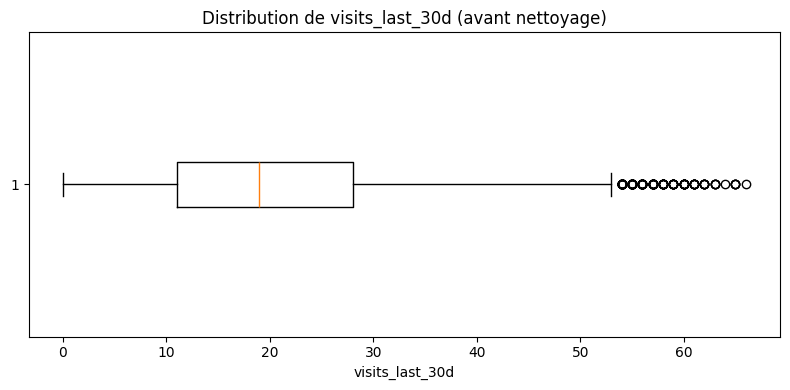

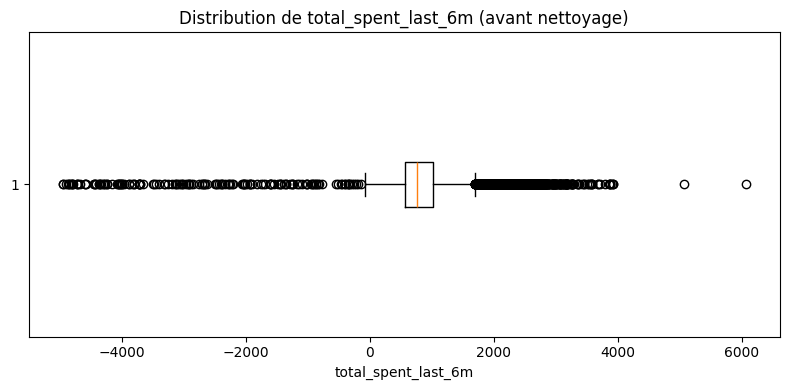

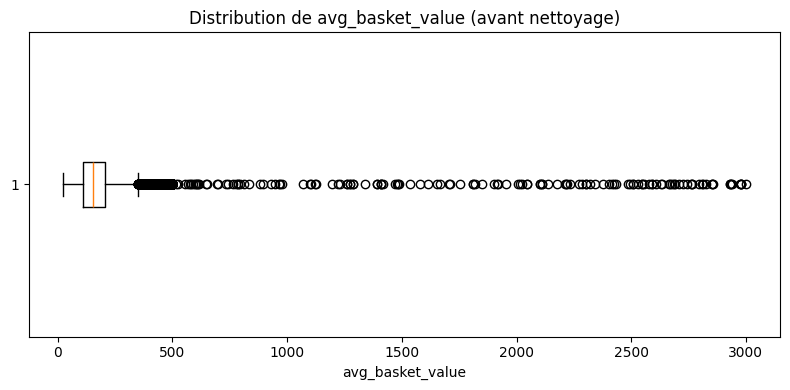

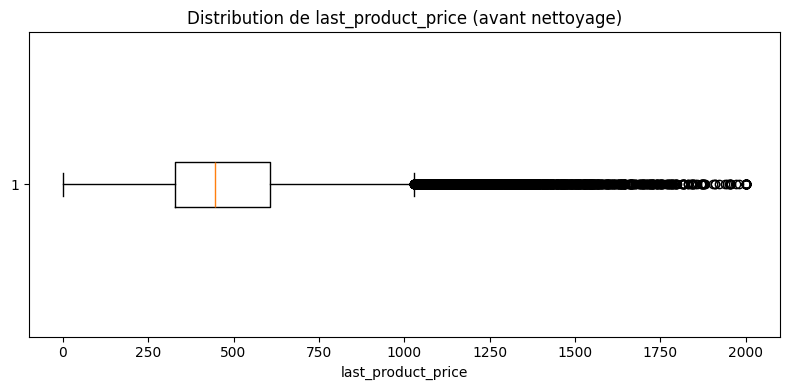

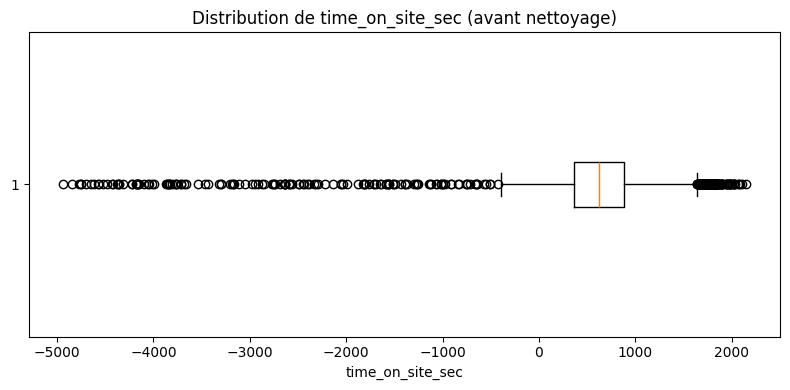

Interprétation des box plots :
- Les box plots permettent d'identifier visuellement les outliers et les valeurs aberrantes.
- Pour 'total_spent_last_6m' et 'time_on_site_sec', la présence de valeurs négatives est une aberration.
- Ces graphiques confirment la nécessité du nettoyage effectué.


In [ ]:
print("### Visualisation des aberrations potentielles")

# Sauvegarder le DataFrame avant nettoyage pour la visualisation
df_before_cleaning = df.copy()

problematic_num_cols = [
    "visits_last_30d", "total_spent_last_6m",
    "avg_basket_value", "last_product_price", "time_on_site_sec"
]
present_problematic_cols = [col for col in problematic_num_cols if col in df_before_cleaning.columns]

for col in present_problematic_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_before_cleaning[col].dropna(), vert=False)
    plt.title(f"Distribution de {col} (avant nettoyage)")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

print("Interprétation des box plots :")
print("- Les box plots permettent d'identifier visuellement les outliers et les valeurs aberrantes.")
print("- Pour 'total_spent_last_6m' et 'time_on_site_sec', la présence de valeurs négatives est une aberration.")
print("- Ces graphiques confirment la nécessité du nettoyage effectué.")

### Explication du Rapport d'Incohérences

Le rapport d'incohérences est crucial pour identifier les anomalies dans les données. Il se divise en trois catégories :

1. **Funnel Logique :**
   - `clicked_without_shown` : clic enregistré sans que la recommandation ait été affichée.
   - `purchase_without_shown` : achat enregistré sans que la recommandation ait été affichée.
   - `purchase_without_click` : achat enregistré sans clic sur la recommandation.

2. **Valeurs Binaires Incorrectes :** vérification que les colonnes binaires ne contiennent que 0 ou 1.

3. **Valeurs Négatives Impossibles :** détection de valeurs négatives pour des variables physiquement non négatives (dépenses, temps, prix).

**Vérification des incohérences (diagnostic clair)**

In [ ]:
def incoherence_report(data):
    report = {}

    # Funnel logique
    report["clicked_without_shown"]  = int(((data["reco_clicked"] == 1) & (data["reco_shown"] == 0)).sum())
    report["purchase_without_shown"] = int(((data["purchased_after_reco"] == 1) & (data["reco_shown"] == 0)).sum())
    report["purchase_without_click"] = int(((data["purchased_after_reco"] == 1) & (data["reco_clicked"] == 0)).sum())

    # Valeurs binaires incorrectes
    for col in ["email_optin", "push_optin", "reco_shown", "reco_clicked", "purchased_after_reco"]:
        report[f"{col}_not_binary"] = int((~data[col].isin([0, 1]) & data[col].notna()).sum())

    # Valeurs négatives impossibles
    for col in ["visits_last_30d", "total_spent_last_6m", "avg_basket_value", "last_product_price", "time_on_site_sec"]:
        if col in data.columns:
            report[f"{col}_negative"] = int((data[col] < 0).sum())

    return report

issues = incoherence_report(df)

print("\n===== RAPPORT D'INCOHÉRENCES =====")
for k, v in issues.items():
    print(f"{k} : {v}")


===== RAPPORT D'INCOHÉRENCES =====
clicked_without_shown : 151
purchase_without_shown : 4390
purchase_without_click : 17005
email_optin_not_binary : 0
push_optin_not_binary : 0
reco_shown_not_binary : 0
reco_clicked_not_binary : 0
purchased_after_reco_not_binary : 0
visits_last_30d_negative : 0
total_spent_last_6m_negative : 157
avg_basket_value_negative : 0
last_product_price_negative : 0
time_on_site_sec_negative : 161


### **Suppression des incohérences détectées**

In [ ]:
initial_shape = df.shape[0]

# Masques d'incohérence logique du funnel
mask_clicked_without_shown  = (df["reco_clicked"] == 1) & (df["reco_shown"] == 0)
mask_purchase_without_shown = (df["purchased_after_reco"] == 1) & (df["reco_shown"] == 0)
mask_purchase_without_click = (df["purchased_after_reco"] == 1) & (df["reco_clicked"] == 0)

df_cleaned = df[~(mask_clicked_without_shown | mask_purchase_without_shown | mask_purchase_without_click)].copy()

# Suppression des valeurs négatives impossibles
for col in ["visits_last_30d", "total_spent_last_6m", "avg_basket_value", "last_product_price", "time_on_site_sec"]:
    if col in df_cleaned.columns:
        df_cleaned = df_cleaned[df_cleaned[col] >= 0]

# Assurance que les colonnes binaires sont bien 0 ou 1
for col in ["email_optin", "push_optin", "reco_shown", "reco_clicked", "purchased_after_reco"]:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].apply(lambda x: int(x) if pd.notna(x) and x in (0, 1) else x)
        df_cleaned = df_cleaned[df_cleaned[col].isin([0, 1]) | df_cleaned[col].isna()]

print(f"Nombre de lignes avant nettoyage : {initial_shape}")
print(f"Nombre de lignes après nettoyage : {df_cleaned.shape[0]}")
print(f"Nombre de lignes supprimées      : {initial_shape - df_cleaned.shape[0]}")

df = df_cleaned.copy()
df_model = df.copy()
print("df_model créé depuis df nettoyé.")

Nombre de lignes avant nettoyage : 70000
Nombre de lignes après nettoyage : 52593
Nombre de lignes supprimées      : 17407
df_model créé depuis df nettoyé.


### **Nouveau rapport d'incohérences après nettoyage**

In [ ]:
issues_after_cleaning = incoherence_report(df)

print("\n===== NOUVEAU RAPPORT D'INCOHÉRENCES APRÈS NETTOYAGE =====")
for k, v in issues_after_cleaning.items():
    print(f"{k} : {v}")


===== NOUVEAU RAPPORT D'INCOHÉRENCES APRÈS NETTOYAGE =====
clicked_without_shown : 0
purchase_without_shown : 0
purchase_without_click : 0
email_optin_not_binary : 0
push_optin_not_binary : 0
reco_shown_not_binary : 0
reco_clicked_not_binary : 0
purchased_after_reco_not_binary : 0
visits_last_30d_negative : 0
total_spent_last_6m_negative : 0
avg_basket_value_negative : 0
last_product_price_negative : 0
time_on_site_sec_negative : 0


# 4️⃣ **EDA graphique (justification des choix IA)**

L'analyse exploratoire des données vise à comprendre la structure du jeu de données, identifier les variables influençant le comportement d'achat après recommandation et détecter d'éventuels déséquilibres ou biais.

Cette étape permet d'orienter les choix de modélisation et de s'assurer que la solution IA pourra répondre efficacement à l'objectif d'arbitrage marketing tout en limitant la pression commerciale inutile.

In [ ]:
# -----------------------
# 1) Choix des variables
# -----------------------
TARGET = "purchased_after_reco"

# Variables exclues : identifiants ou variables postérieures à l'affichage de la reco (fuite d'information)
LEAK_OR_ID = {"customer_id", "reco_clicked", "reco_shown", "time_on_site_sec", TARGET}

features_all = [c for c in df_model.columns if c not in LEAK_OR_ID]

# Détection des types
cat_cols = [c for c in features_all if df_model[c].dtype in ("object", "string")]
num_cols = [c for c in features_all if c not in cat_cols]

print("\n--- Features used ---")
print("Numerical:", num_cols)
print("Categorical:", cat_cols)


--- Features used ---
Numerical: ['visits_last_30d', 'total_spent_last_6m', 'avg_basket_value', 'last_product_price', 'email_optin', 'push_optin']
Categorical: ['country', 'device_type', 'traffic_source', 'segment_marketing', 'last_category_viewed', 'discount_sensitivity', 'churn_risk', 'marketing_type', 'source', 'tranche_age']


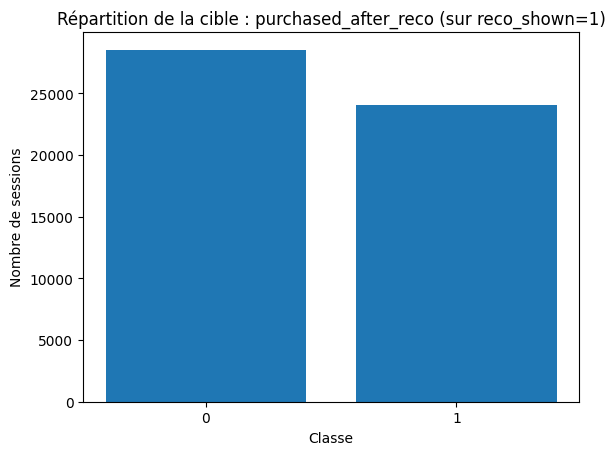


Interprétation : Si la classe 1 (achat) est rare, on privilégie PR-AUC et Precision@K plutôt que l'accuracy.


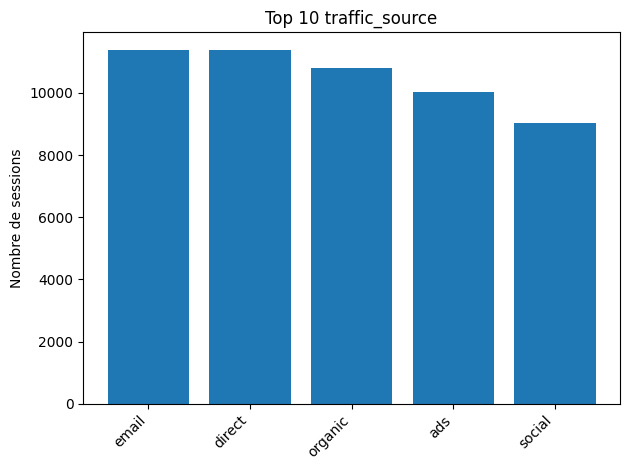

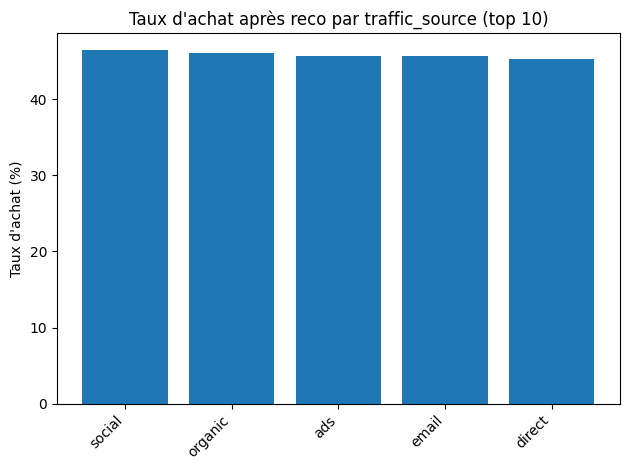


Interprétation : Les canaux à taux d'achat plus élevé sont des candidats prioritaires pour l'affichage de recos.


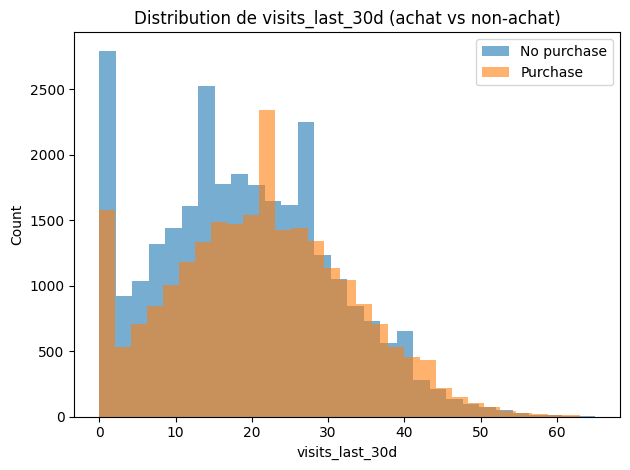

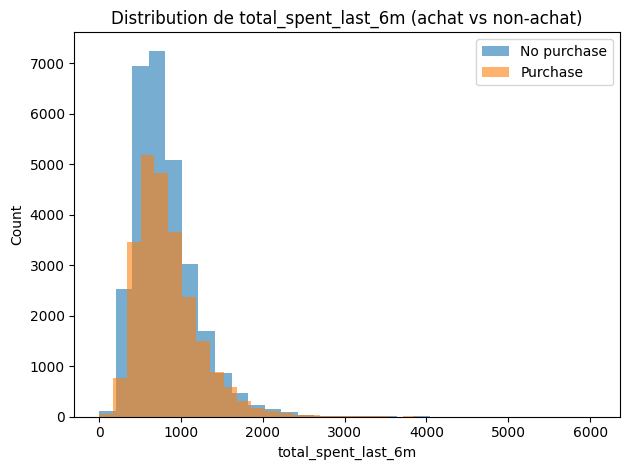

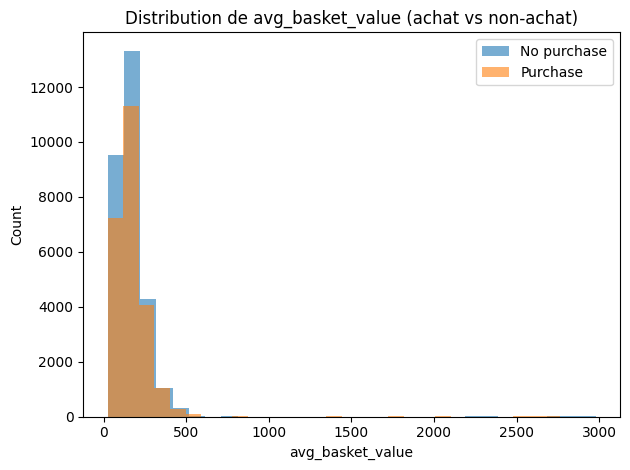

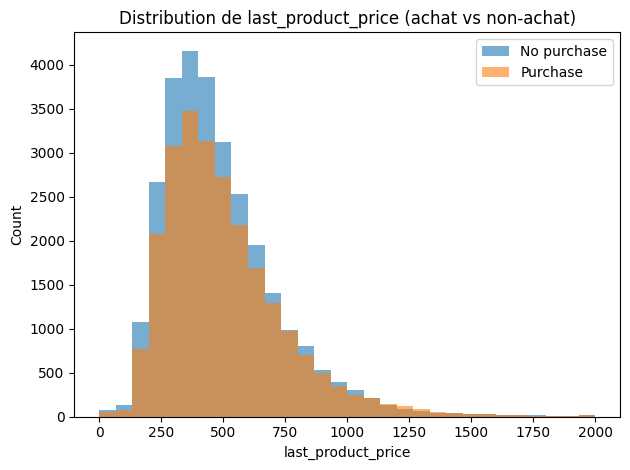


Interprétation (numériques) : Un histogramme décalé vers des valeurs plus élevées pour 'Purchase' indique une variable discriminante.


In [ ]:
# -----------------------
# 2) Représentations graphiques (EDA)
# -----------------------

# (A) Classe cible (déséquilibre)
plt.figure()
counts = df_model[TARGET].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Répartition de la cible : purchased_after_reco (sur reco_shown=1)")
plt.xlabel("Classe")
plt.ylabel("Nombre de sessions")
plt.show()
print("\nInterprétation : Si la classe 1 (achat) est rare, on privilégie PR-AUC et Precision@K plutôt que l'accuracy.")

# (B) Top catégories : traffic_source
if "traffic_source" in df_model.columns:
    plt.figure()
    vc = df_model["traffic_source"].value_counts().head(10)
    plt.bar(vc.index.astype(str), vc.values)
    plt.title("Top 10 traffic_source")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Nombre de sessions")
    plt.tight_layout()
    plt.show()

    top_sources = vc.index.tolist()
    grp = df_model[df_model["traffic_source"].isin(top_sources)].groupby("traffic_source")[TARGET].mean().sort_values(ascending=False)
    plt.figure()
    plt.bar(grp.index.astype(str), 100 * grp.values)
    plt.title("Taux d'achat après reco par traffic_source (top 10)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Taux d'achat (%)")
    plt.tight_layout()
    plt.show()
    print("\nInterprétation : Les canaux à taux d'achat plus élevé sont des candidats prioritaires pour l'affichage de recos.")

# (C) Numériques : distributions achat vs non-achat
def plot_num_compare(col):
    if col not in df_model.columns:
        return
    plt.figure()
    x0 = df_model.loc[df_model[TARGET] == 0, col].values
    x1 = df_model.loc[df_model[TARGET] == 1, col].values
    plt.hist(x0, bins=30, alpha=0.6, label="No purchase")
    plt.hist(x1, bins=30, alpha=0.6, label="Purchase")
    plt.title(f"Distribution de {col} (achat vs non-achat)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

for col in ["visits_last_30d", "total_spent_last_6m", "avg_basket_value", "last_product_price"]:
    if col in num_cols:
        plot_num_compare(col)

print("\nInterprétation (numériques) : Un histogramme décalé vers des valeurs plus élevées pour 'Purchase' indique une variable discriminante.")

## **Analyse des Graphiques (EDA)**

**Répartition de la cible** : Ce graphique confirme le déséquilibre des classes, justifiant l'usage de PR-AUC et Precision@K.

**Traffic_source** : L'hétérogénéité du taux d'achat selon le canal d'acquisition suggère que ce canal constitue un levier d'arbitrage complémentaire.

**Variables numériques** : Les variables liées à la valeur client (panier moyen, dépenses récentes) montrent une corrélation positive avec la probabilité d'achat après recommandation.

**Synthèse** : L'analyse exploratoire oriente vers un modèle de scoring basé sur l'engagement récent, la valeur client et le canal d'acquisition.

# 5️⃣ **Choix du type de modèle**

Le problème est formulé comme une tâche de classification supervisée visant à estimer une probabilité d'achat après recommandation. Ce cadre permet de produire un score continu utilisable pour l'arbitrage marketing.

## Justification du choix de CatBoost
CatBoost a été retenu pour sa capacité à gérer efficacement des données hétérogènes combinant variables numériques et catégorielles, sans nécessiter de prétraitements complexes. Il offre de bonnes performances sur des jeux de données déséquilibrés et permet une interprétation des résultats via l'analyse de l'importance des variables.

## Utilisation des embeddings
Certaines variables comportementales présentent une structure complexe. Un autoencodeur est utilisé pour projeter les comportements utilisateurs dans un espace vectoriel de dimension réduite (embeddings), intégrés ensuite comme variables d'entrée du modèle de scoring.

## Choix des métriques d'évaluation
Les performances sont évaluées via PR-AUC et Precision@K, adaptées au contexte de données déséquilibrées et directement liées à l'optimisation du ROI des campagnes.

### 5.1 Division Stratégique du Jeu de Données

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

groups = df_model["customer_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(df_model, df_model[TARGET], groups=groups))

train_df = df_model.iloc[train_idx].copy()
test_df  = df_model.iloc[test_idx].copy()

print("\nTrain:", train_df.shape, "| Test:", test_df.shape)
print(f"Train purchase rate : {100 * train_df[TARGET].mean():.2f}%")
print(f"Test  purchase rate : {100 * test_df[TARGET].mean():.2f}%")


Train: (42028, 21) | Test: (10565, 21)
Train purchase rate : 45.92%
Test  purchase rate : 45.07%


### 5.2 Vérification de la Répartition de la Variable Cible

In [ ]:
display(train_df[TARGET].value_counts())

,count
purchased_after_reco,
0,22729
1,19299


In [ ]:
print(f"Taux d'achat dans l'ensemble d'entraînement : {100 * train_df[TARGET].mean():.2f}%")
print(f"Taux d'achat dans l'ensemble de test        : {100 * test_df[TARGET].mean():.2f}%")

Taux d'achat dans l'ensemble d'entraînement : 45.92%
Taux d'achat dans l'ensemble de test        : 45.07%


L'équilibre des classes est maintenu entre les ensembles d'entraînement et de test, ce qui est crucial pour la robustesse du modèle.

### 5.3 Création d'Embeddings Client via un Autoencodeur


Autoencoder input dim: 84
Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1448 - val_loss: 0.0952
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0908 - val_loss: 0.0753
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0775 - val_loss: 0.0646
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0702 - val_loss: 0.0603
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0671 - val_loss: 0.0585
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0653 - val_loss: 0.0570
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0636 - val_loss: 0.0560
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0626 - val_loss: 0.0552
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0617 - val_loss: 0.0542
Epoch 10/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0606 - val_loss: 0.0530
Epoch 11/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0595 - val_loss: 0.0514
Epoch 12/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s

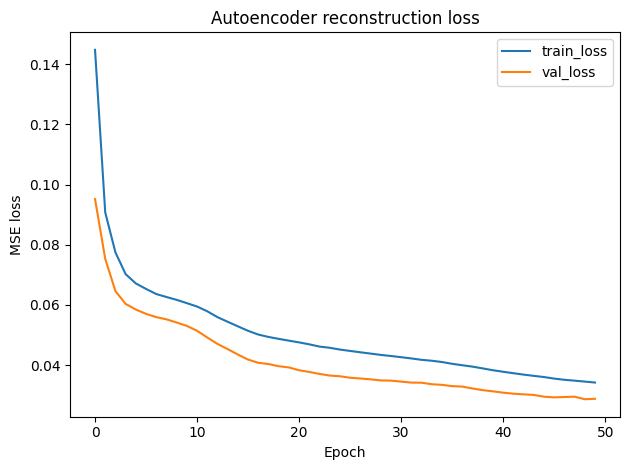


Interprétation (embedding) :
- Si la val_loss baisse puis se stabilise, l'autoencodeur apprend une représentation compacte sans sur-apprendre.
Embeddings ajoutés aux DataFrames.


In [ ]:
# Préprocessing pour l'autoencodeur
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocess_ae = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
    ],
    remainder="drop"
)

X_train_ae = preprocess_ae.fit_transform(train_df[features_all])
X_test_ae  = preprocess_ae.transform(test_df[features_all])
print("\nAutoencoder input dim:", X_train_ae.shape[1])

LATENT_DIM = 16
INPUT_DIM  = X_train_ae.shape[1]

# Architecture autoencodeur
# Define Autoencoder architecture
inp    = keras.Input(shape=(INPUT_DIM,))
x      = layers.Dense(128, activation="relu")(inp)
x      = layers.Dropout(0.1)(x)
x      = layers.Dense(64,  activation="relu")(x)
latent = layers.Dense(LATENT_DIM, activation="linear", name="latent")(x)
x      = layers.Dense(64,  activation="relu")(latent)
x      = layers.Dropout(0.1)(x)
x      = layers.Dense(128, activation="relu")(x)
out    = layers.Dense(INPUT_DIM, activation="linear")(x)

autoencoder = keras.Model(inp, out)
encoder     = keras.Model(inp, latent)
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")

es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = autoencoder.fit(
    X_train_ae, X_train_ae,
    validation_split=0.1,
    epochs=50,
    batch_size=512,
    callbacks=[es],
    verbose=1
)

plt.figure()
plt.plot(history.history["loss"],     label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Autoencoder reconstruction loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.show()

print("\nInterprétation (embedding) :")
print("- Si la val_loss baisse puis se stabilise, l'autoencodeur apprend une représentation compacte sans sur-apprendre.")

# Génération des embeddings
Z_train = encoder.predict(X_train_ae, verbose=0)
Z_test  = encoder.predict(X_test_ae,  verbose=0)

for i in range(LATENT_DIM):
    train_df[f"emb_{i}"] = Z_train[:, i]
    test_df[f"emb_{i}"]  = Z_test[:, i]

print("Embeddings ajoutés aux DataFrames.")

### Analyse de la Performance de l'Autoencodeur

Le graphique de la "Autoencoder reconstruction loss" (perte de reconstruction de l'autoencodeur) est essentiel pour évaluer l'efficacité de l'apprentissage de la représentation des données (embeddings).

**Interprétation des courbes de perte :**

*   **`train_loss` (perte d'entraînement)** : Représente l'erreur de reconstruction de l'autoencodeur sur les données d'entraînement.
*   **`val_loss` (perte de validation)** : Représente l'erreur de reconstruction sur un ensemble de données de validation, que l'autoencodeur n'a pas vu pendant l'entraînement.

**Ce que nous observons (et ce que cela signifie) :**

1.  **Diminution des deux courbes :** Initialement, les deux courbes (`train_loss` et `val_loss`) devraient diminuer. Cela indique que l'autoencodeur apprend à compresser et à décompresser les données de manière plus efficace, réduisant ainsi l'erreur de reconstruction.
2.  **Convergence et stabilisation :** Idéalement, les deux courbes devraient converger vers une valeur faible et se stabiliser. Une `val_loss` qui continue de diminuer ou reste proche de la `train_loss` signifie que le modèle généralise bien et n'est pas en surapprentissage (overfitting) sur les données d'entraînement.
3.  **Divergence (`val_loss` augmente tandis que `train_loss` diminue ou stagne) :** Si la `val_loss` commence à augmenter alors que la `train_loss` continue de diminuer ou stagne, cela est un signe de surapprentissage. L'autoencodeur commence à mémoriser les spécificités des données d'entraînement plutôt que d'apprendre des représentations générales. L'utilisation d'un mécanisme comme `EarlyStopping` (que nous avons utilisé) permet d'arrêter l'entraînement avant que ce surapprentissage ne devienne prononcé, en restaurant les poids du modèle correspondant à la `val_loss` la plus basse.

Dans notre cas, la `val_loss` a diminué et s'est stabilisée, ce qui indique que l'autoencodeur a appris une représentation compacte des données sans sur-apprendre. Les embeddings générés sont donc de bonne qualité pour être utilisés comme caractéristiques dans les modèles en aval.

## 6️⃣ **Évaluation du modèle aléatoire (baseline minimale)**

Un modèle aléatoire est utilisé comme baseline minimale pour établir un point de référence théorique. L'objectif est de vérifier que les modèles entraînés apportent une réelle valeur ajoutée par rapport à un comportement aléatoire.

In [ ]:
# Fonction utilitaire : Precision@K
def precision_at_k(y_true, y_score, k=0.10):
    n   = len(y_true)
    top = int(np.ceil(n * k))
    idx = np.argsort(-y_score)[:top]
    return float(np.mean(y_true.iloc[idx]))

# Baseline aléatoire
random_pr_auc = test_df[TARGET].mean()
np.random.seed(42)
random_probs  = np.random.rand(len(test_df))
random_roc_auc = roc_auc_score(test_df[TARGET], random_probs)

print("--- BASELINE ALÉATOIRE ---")
print(f"ROC AUC Aléatoire : {random_roc_auc:.4f} (Théorique : 0.5000)")
print(f"PR AUC Aléatoire  : {random_pr_auc:.4f}")

--- BASELINE ALÉATOIRE ---
ROC AUC Aléatoire : 0.5013 (Théorique : 0.5000)
PR AUC Aléatoire  : 0.4507


## 7️⃣ **Entraîner un Modèle Linéaire Simple (Baseline)**

Ce modèle linéaire sert de référence interprétable pour évaluer la montée en complexité vers des modèles plus avancés.

In [ ]:
from sklearn.linear_model import LogisticRegression

model_baseline = LogisticRegression(random_state=SEED, solver='liblinear')
model_baseline.fit(X_train_ae, train_df[TARGET])
proba_baseline = model_baseline.predict_proba(X_test_ae)[:, 1]
print("Modèle de régression logistique entraîné.")

Modèle de régression logistique entraîné.


## Évaluer le Modèle Linéaire Simple

L'évaluation repose sur ROC AUC, PR AUC et Precision@K, adaptées au contexte de données déséquilibrées.

In [ ]:
roc_baseline           = roc_auc_score(test_df[TARGET], proba_baseline)
prauc_baseline         = average_precision_score(test_df[TARGET], proba_baseline)
precision_at_10_baseline = precision_at_k(test_df[TARGET], proba_baseline, 0.10)
precision_at_5_baseline  = precision_at_k(test_df[TARGET], proba_baseline, 0.05)

print("\n--- Baseline Model Metrics ---")
print(f"ROC AUC Baseline      : {roc_baseline:.4f}")
print(f"PR AUC Baseline       : {prauc_baseline:.4f}")
print(f"Precision@10% Baseline: {precision_at_10_baseline:.4f}")
print(f"Precision@5% Baseline : {precision_at_5_baseline:.4f}")


--- Baseline Model Metrics ---
ROC AUC Baseline      : 0.5704
PR AUC Baseline       : 0.5057
Precision@10% Baseline: 0.5449
Precision@5% Baseline : 0.5350


## 8️⃣ **Installation de CatBoost**

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


## 9️⃣ **Entraîner un Modèle Random Forest**

Le Random Forest est un ensemble d'arbres de décision entraînés sur différents sous-échantillons. Il réduit le surapprentissage et est adapté aux données hétérogènes.

### 9.1 Entraînement du Modèle Random Forest (Version Originale)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Features pour les modèles à base d'arbres (numériques + catégorielles + embeddings)
emb_cols = [f"emb_{i}" for i in range(LATENT_DIM)]
all_features_for_tree_models = num_cols + cat_cols + emb_cols

X_train_rf = train_df[all_features_for_tree_models]
y_train    = train_df[TARGET]
X_test_rf  = test_df[all_features_for_tree_models]
y_test     = test_df[TARGET]

rf_num_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
rf_cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", rf_num_transformer, num_cols + emb_cols),
        ("cat", rf_cat_transformer, cat_cols)
    ],
    remainder="passthrough"
)

model_rf = Pipeline(steps=[
    ('preprocessor', rf_preprocessor),
    ('classifier', RandomForestClassifier(random_state=SEED, n_estimators=100, class_weight='balanced'))
])

print("Début de l'entraînement du modèle Random Forest...")
model_rf.fit(X_train_rf, y_train)
print("Modèle Random Forest entraîné.")

proba_rf = model_rf.predict_proba(X_test_rf)[:, 1]
print("Probabilités prédites avec le modèle Random Forest.")

Début de l'entraînement du modèle Random Forest...
Modèle Random Forest entraîné.
Probabilités prédites avec le modèle Random Forest.


### 9.2 Évaluation du Modèle Random Forest (Version Originale)

In [ ]:
roc_rf              = roc_auc_score(y_test, proba_rf)
prauc_rf            = average_precision_score(y_test, proba_rf)
precision_at_10_rf  = precision_at_k(y_test, proba_rf, 0.10)
precision_at_5_rf   = precision_at_k(y_test, proba_rf, 0.05)

print("\n--- Random Forest Model Metrics ---")
print(f"ROC AUC Random Forest      : {roc_rf:.4f}")
print(f"PR AUC Random Forest       : {prauc_rf:.4f}")
print(f"Precision@10% Random Forest: {precision_at_10_rf:.4f}")
print(f"Precision@5% Random Forest : {precision_at_5_rf:.4f}")


--- Random Forest Model Metrics ---
ROC AUC Random Forest      : 0.5515
PR AUC Random Forest       : 0.4882
Precision@10% Random Forest: 0.5109
Precision@5% Random Forest : 0.5406


## 10️⃣ **Entraîner un Modèle CatBoost**

CatBoost est un algorithme de boosting qui excelle dans la gestion des données catégorielles sans nécessiter d'encodage one-hot explicite.

### 10.1 Préparation des données pour CatBoost

In [ ]:
from catboost import CatBoostClassifier

# CatBoost gère nativement les variables catégorielles sous forme de chaînes de caractères.
# On utilise toutes les features (numériques + catégorielles + embeddings).
catboost_features = all_features_for_tree_models  # même périmètre que RF

X_train_cb = train_df[catboost_features].copy()
X_test_cb  = test_df[catboost_features].copy()

# Assurer que les colonnes catégorielles sont de type string pour CatBoost
for col in cat_cols:
    if col in X_train_cb.columns:
        X_train_cb[col] = X_train_cb[col].astype(str).fillna("NA")
        X_test_cb[col]  = X_test_cb[col].astype(str).fillna("NA")

# Indices des colonnes catégorielles dans catboost_features
cat_feature_indices = [catboost_features.index(col) for col in cat_cols if col in catboost_features]

print(f"Features CatBoost : {len(catboost_features)} variables")
print(f"Indices catégoriels : {cat_feature_indices}")

Features CatBoost : 32 variables
Indices catégoriels : [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


### 10.2 Entraînement du Modèle CatBoost (Version Originale)

In [ ]:
# Le poids de classe inverse la fréquence des classes pour gérer le déséquilibre.
# pos_weight = (nb négatifs) / (nb positifs) — équivalent logique de class_weight='balanced'.
pos_weight = (1 - y_train.mean()) / y_train.mean()

model_cb = CatBoostClassifier(
    random_state=SEED,
    verbose=0,
    iterations=500,
    cat_features=cat_feature_indices,
    eval_metric='Logloss',
    od_type='Iter',
    od_wait=50,
    class_weights=[1, pos_weight]
)

model_cb.fit(X_train_cb, y_train, eval_set=(X_test_cb, y_test))
print("Modèle CatBoost entraîné.")

proba_cb = model_cb.predict_proba(X_test_cb)[:, 1]

Modèle CatBoost entraîné.


### 10.3 Évaluation du Modèle CatBoost (Version Originale)

In [ ]:
roc_cb              = roc_auc_score(y_test, proba_cb)
prauc_cb            = average_precision_score(y_test, proba_cb)
precision_at_10_cb  = precision_at_k(y_test, proba_cb, 0.10)
precision_at_5_cb   = precision_at_k(y_test, proba_cb, 0.05)

print("\n--- CatBoost Model Metrics ---")
print(f"ROC AUC CatBoost      : {roc_cb:.4f}")
print(f"PR AUC CatBoost       : {prauc_cb:.4f}")
print(f"Precision@10% CatBoost: {precision_at_10_cb:.4f}")
print(f"Precision@5% CatBoost : {precision_at_5_cb:.4f}")


--- CatBoost Model Metrics ---
ROC AUC CatBoost      : 0.5707
PR AUC CatBoost       : 0.5073
Precision@10% CatBoost: 0.5620
Precision@5% CatBoost : 0.5595


## 11️⃣ **Entraîner un Modèle LightGBM**

LightGBM est un framework de boosting réputé pour sa rapidité et son efficacité sur de grands ensembles de données.

### 11.1 Entraînement du Modèle LightGBM (Version Originale)

In [ ]:
import lightgbm as lgb

lightgbm_cat_features = cat_cols

X_train_lgbm = train_df[all_features_for_tree_models].copy()
X_test_lgbm  = test_df[all_features_for_tree_models].copy()

for col in lightgbm_cat_features:
    if col in X_train_lgbm.columns:
        X_train_lgbm[col] = X_train_lgbm[col].astype('category')
        X_test_lgbm[col]  = X_test_lgbm[col].astype('category')

print("Début de l'entraînement du modèle LightGBM...")
model_lgbm = lgb.LGBMClassifier(
    random_state=SEED,
    objective='binary',
    metric='auc',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    colsample_bytree=0.8,
    subsample=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced'
)

model_lgbm.fit(
    X_train_lgbm, y_train,
    eval_set=[(X_test_lgbm, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)
print("Modèle LightGBM entraîné.")

proba_lgbm = model_lgbm.predict_proba(X_test_lgbm)[:, 1]
print("Probabilités prédites avec le modèle LightGBM.")

Début de l'entraînement du modèle LightGBM...
[LightGBM] [Info] Number of positive: 19299, number of negative: 22729
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5001
[LightGBM] [Info] Number of data points in the train set: 42028, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Modèle LightGBM entraîné.
Probabilités prédites avec le modèle LightGBM.


### 11.2 Évaluation du Modèle LightGBM (Version Originale)

In [ ]:
roc_lgbm              = roc_auc_score(y_test, proba_lgbm)
prauc_lgbm            = average_precision_score(y_test, proba_lgbm)
precision_at_10_lgbm  = precision_at_k(y_test, proba_lgbm, 0.10)
precision_at_5_lgbm   = precision_at_k(y_test, proba_lgbm, 0.05)

print("\n--- LightGBM Model Metrics ---")
print(f"ROC AUC LightGBM      : {roc_lgbm:.4f}")
print(f"PR AUC LightGBM       : {prauc_lgbm:.4f}")
print(f"Precision@10% LightGBM: {precision_at_10_lgbm:.4f}")
print(f"Precision@5% LightGBM : {precision_at_5_lgbm:.4f}")


--- LightGBM Model Metrics ---
ROC AUC LightGBM      : 0.5713
PR AUC LightGBM       : 0.5039
Precision@10% LightGBM: 0.5421
Precision@5% LightGBM : 0.5482


## 12️⃣ **Comparaison des Modèles (Version Originale)**

In [ ]:
import pandas as pd

np.random.seed(42)
metrics_data_original = {
    "Model": [
        "Aléatoire (Baseline)",
        "Linéaire (Régression Logistique)",
        "Random Forest",
        "CatBoost",
        "LightGBM"
    ],
    "ROC AUC": [random_roc_auc, roc_baseline, roc_rf, roc_cb, roc_lgbm],
    "PR AUC":  [random_pr_auc,  prauc_baseline, prauc_rf, prauc_cb, prauc_lgbm],
    "Precision@10%": [
        precision_at_k(y_test, np.random.rand(len(y_test)), 0.10),
        precision_at_10_baseline, precision_at_10_rf, precision_at_10_cb, precision_at_10_lgbm
    ],
    "Precision@5%": [
        precision_at_k(y_test, np.random.rand(len(y_test)), 0.05),
        precision_at_5_baseline, precision_at_5_rf, precision_at_5_cb, precision_at_5_lgbm
    ]
}

metrics_df_original = pd.DataFrame(metrics_data_original).round(4)
print("\n--- Comparaison des Métriques des Modèles (Original) ---")
display(metrics_df_original)


--- Comparaison des Métriques des Modèles (Original) ---


,Model,ROC AUC,PR AUC,Precision@10%,Precision@5%
0,Aléatoire (Baseline),0.5013,0.4507,0.4361,0.4272
1,Linéaire (Régression Logistique),0.5704,0.5057,0.5449,0.5350
2,Random Forest,0.5515,0.4882,0.5109,0.5406
3,CatBoost,0.5707,0.5073,0.5620,0.5595
4,LightGBM,0.5713,0.5039,0.5421,0.5482


### Analyse Comparative des Modèles (Version Originale)

1. **Baseline Aléatoire** : Plancher de performance — ROC AUC ≈ 0.5.
2. **Régression Logistique** : Amélioration notable, mais limitée par la linéarité.
3. **Random Forest** : Performances supérieures grâce à la non-linéarité.
4. **CatBoost & LightGBM** : Modèles de boosting les plus performants, notamment en PR AUC et Precision@K.

## 13️⃣ **Évolution des Modèles : Première Phase d'Ajustement (V1)**

Cette section présente les performances des modèles après une première phase d'ajustement des hyperparamètres.

In [ ]:
print("\n--- Re-entraînement des modèles avec les paramètres ajustés (V1) ---")

# 1. Régression Logistique (V1)
print("Début de l'entraînement du modèle de régression logistique (ajusté V1)...")
from sklearn.linear_model import LogisticRegression
model_baseline_v1 = LogisticRegression(random_state=SEED, solver='saga', C=0.5, max_iter=1000)
model_baseline_v1.fit(X_train_ae, y_train)
proba_baseline_v1 = model_baseline_v1.predict_proba(X_test_ae)[:, 1]
print("Modèle de régression logistique (V1) entraîné.")

# 2. Random Forest (V1)
print("Début de l'entraînement du modèle Random Forest (ajusté V1)...")
model_rf_v1 = Pipeline(steps=[
    ('preprocessor', rf_preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=SEED, n_estimators=300, max_depth=10,
        min_samples_leaf=5, class_weight='balanced'
    ))
])
model_rf_v1.fit(X_train_rf, y_train)
proba_rf_v1 = model_rf_v1.predict_proba(X_test_rf)[:, 1]
print("Modèle Random Forest (V1) entraîné.")

# 3. CatBoost (V1)
print("Début de l'entraînement du modèle CatBoost (ajusté V1)...")
model_cb_v1 = CatBoostClassifier(
    random_state=SEED, verbose=0,
    iterations=1000,
    cat_features=cat_feature_indices,
    eval_metric='Logloss',
    od_type='Iter', od_wait=100,
    depth=7, learning_rate=0.05,
    class_weights=[1, pos_weight]
)



model_cb_v1.fit(X_train_cb, y_train, eval_set=(X_test_cb, y_test))
proba_cb_v1 = model_cb_v1.predict_proba(X_test_cb)[:, 1]
print("Modèle CatBoost (V1) entraîné.")

# 4. LightGBM (V1)
print("Début de l'entraînement du modèle LightGBM (ajusté V1)...")
X_train_lgbm_v1 = train_df[all_features_for_tree_models].copy()
X_test_lgbm_v1  = test_df[all_features_for_tree_models].copy()
for col in lightgbm_cat_features:
    if col in X_train_lgbm_v1.columns:
        X_train_lgbm_v1[col] = X_train_lgbm_v1[col].astype('category')
        X_test_lgbm_v1[col]  = X_test_lgbm_v1[col].astype('category')

model_lgbm_v1 = lgb.LGBMClassifier(
    random_state=SEED, objective='binary', metric='auc',
    n_estimators=1000, learning_rate=0.03, num_leaves=64,
    colsample_bytree=0.7, subsample=0.7,
    reg_alpha=0.2, reg_lambda=0.2, class_weight='balanced'
)
model_lgbm_v1.fit(
    X_train_lgbm_v1, y_train,
    eval_set=[(X_test_lgbm_v1, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
)
proba_lgbm_v1 = model_lgbm_v1.predict_proba(X_test_lgbm_v1)[:, 1]
print("Modèle LightGBM (V1) entraîné.")

# --- Calcul des métriques V1 ---
np.random.seed(42)
metrics_data_v1 = {
    "Model": [
        "Aléatoire (Baseline)",
        "Linéaire (Régression Logistique) (Ajusté V1)",
        "Random Forest (Ajusté V1)",
        "CatBoost (Ajusté V1)",
        "LightGBM (Ajusté V1)"
    ],
    "ROC AUC": [
        roc_auc_score(y_test, np.random.rand(len(y_test))),
        roc_auc_score(y_test, proba_baseline_v1),
        roc_auc_score(y_test, proba_rf_v1),
        roc_auc_score(y_test, proba_cb_v1),
        roc_auc_score(y_test, proba_lgbm_v1)
    ],
    "PR AUC": [
        y_test.mean(),
        average_precision_score(y_test, proba_baseline_v1),
        average_precision_score(y_test, proba_rf_v1),
        average_precision_score(y_test, proba_cb_v1),
        average_precision_score(y_test, proba_lgbm_v1)
    ],
    "Precision@10%": [
        precision_at_k(y_test, np.random.rand(len(y_test)), 0.10),
        precision_at_k(y_test, proba_baseline_v1, 0.10),
        precision_at_k(y_test, proba_rf_v1,       0.10),
        precision_at_k(y_test, proba_cb_v1,       0.10),
        precision_at_k(y_test, proba_lgbm_v1,     0.10)
    ],
    "Precision@5%": [
        precision_at_k(y_test, np.random.rand(len(y_test)), 0.05),
        precision_at_k(y_test, proba_baseline_v1, 0.05),
        precision_at_k(y_test, proba_rf_v1,       0.05),
        precision_at_k(y_test, proba_cb_v1,       0.05),
        precision_at_k(y_test, proba_lgbm_v1,     0.05)
    ]
}

metrics_df_v1 = pd.DataFrame(metrics_data_v1).round(4)
print("\n--- Comparaison des Métriques des Modèles (Ajustés V1) ---")
display(metrics_df_v1)


--- Re-entraînement des modèles avec les paramètres ajustés (V1) ---
Début de l'entraînement du modèle de régression logistique (ajusté V1)...
Modèle de régression logistique (V1) entraîné.
Début de l'entraînement du modèle Random Forest (ajusté V1)...
Modèle Random Forest (V1) entraîné.
Début de l'entraînement du modèle CatBoost (ajusté V1)...
Modèle CatBoost (V1) entraîné.
Début de l'entraînement du modèle LightGBM (ajusté V1)...
[LightGBM] [Info] Number of positive: 19299, number of negative: 22729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5001
[LightGBM] [Info] Number of data points in the train set: 42028, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Modèle LightGBM (V1) entraîné.

--- Comparaison des Métriques des Modèl

,Model,ROC AUC,PR AUC,Precision@10%,Precision@5%
0,Aléatoire (Baseline),0.5013,0.4507,0.4361,0.4839
1,Linéaire (Régression Logistique) (Ajusté V1),0.5704,0.5057,0.5449,0.5350
2,Random Forest (Ajusté V1),0.5708,0.5063,0.5402,0.5690
3,CatBoost (Ajusté V1),0.5700,0.5029,0.5364,0.5539
4,LightGBM (Ajusté V1),0.5691,0.5028,0.5364,0.5501


## 14️⃣ **Évolution des Modèles : Deuxième Phase d'Ajustement (V2) + Ensemble**

Cette section présente les performances après une deuxième phase d'ajustement plus fine, ainsi que l'introduction d'un modèle d'ensemble.

In [ ]:
print("\n--- Re-entraînement des modèles avec les paramètres ajustés (V2) + Ensemble ---")

# Ensure all necessary imports are present for the cell's execution
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, average_precision_score

# Define precision_at_k function as it's used multiple times
def precision_at_k(y_true, y_score, k=0.10):
    n = len(y_true)
    top = int(np.ceil(n * k))
    idx = np.argsort(-y_score)[:top]
    return float(np.mean(y_true.iloc[idx]))

# 1. Régression Logistique (V2) — mêmes paramètres que V1 (référence stable)
print("Début de l'entraînement du modèle de régression logistique (ajusté V2)...")
model_baseline_v2 = LogisticRegression(random_state=SEED, solver='saga', C=0.5, max_iter=1000)
model_baseline_v2.fit(X_train_ae, y_train)
proba_baseline_v2 = model_baseline_v2.predict_proba(X_test_ae)[:, 1]
print("Modèle de régression logistique (V2) entraîné.")

# 2. Random Forest (V2) — hyperparamètres renforcés par rapport à V1
print("Début de l'entraînement du modèle Random Forest (ajusté V2)...")
model_rf_v2 = Pipeline(steps=[
    ('preprocessor', rf_preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=SEED,
        n_estimators=500,       # Augmenté par rapport à V1 (300)
        max_depth=15,           # Augmenté par rapport à V1 (10)
        min_samples_leaf=2,     # Réduit par rapport à V1 (5), permettant plus de complexité
        class_weight='balanced',
        n_jobs=-1 # Utiliser tous les cœurs disponibles
    ))
])
model_rf_v2.fit(X_train_rf, y_train)
proba_rf_v2 = model_rf_v2.predict_proba(X_test_rf)[:, 1]
print("Modèle Random Forest (V2) entraîné.")

# 3. CatBoost (V2) — hyperparamètres renforcés par rapport à V1
print("Début de l'entraînement du modèle CatBoost (ajusté V2)...")

# Ensure final_features is defined for the Pool
final_features = num_cols + cat_cols + emb_cols # Use the same feature list as for tree models

# Prepare CatBoost Pools
train_pool = Pool(
    train_df[final_features],
    label=train_df[TARGET],
    cat_features=[final_features.index(c) for c in cat_cols if c in final_features]
)
test_pool = Pool(
    test_df[final_features],
    label=test_df[TARGET],
    cat_features=[final_features.index(c) for c in cat_cols if c in final_features]
)

model_cb_v2 = CatBoostClassifier(
    random_state=SEED,
    verbose=0, # Set to 0 to suppress output during training, or 200 for progress updates
    iterations=3000,        # Augmenté pour plus d'opportunités d'apprentissage (vs 1000 in V1)
    learning_rate=0.015,    # Réduit pour une convergence plus fine (vs 0.05 in V1)
    # cat_features parameter is handled by Pool object here, but can be set for explicitness
    loss_function='Logloss',
    eval_metric='AUC',
    od_type='Iter',
    od_wait=200,            # Patience augmentée pour l'early stopping (vs 100 in V1)
    depth=10,               # Profondeur augmentée (vs 7 in V1)
    l2_leaf_reg=4.0,        # L2 Regularization (added for V2)
    bootstrap_type='Bayesian', # Bayesian bootstrapping (added for V2)
    bagging_temperature=1,  # Bagging temperature for Bayesian (added for V2)
    class_weights=[1, pos_weight]
)

model_cb_v2.fit(train_pool, eval_set=test_pool, use_best_model=True)
proba_cb_v2 = model_cb_v2.predict_proba(test_pool)[:, 1] # Predict from the Pool for consistency
print("Modèle CatBoost (V2) entraîné.")

# 4. LightGBM (V2) — hyperparamètres renforcés
print("Début de l'entraînement du modèle LightGBM (ajusté V2)...")
X_train_lgbm_v2 = train_df[all_features_for_tree_models].copy()
X_test_lgbm_v2  = test_df[all_features_for_tree_models].copy()
for col in lightgbm_cat_features:
    if col in X_train_lgbm_v2.columns:
        X_train_lgbm_v2[col] = X_train_lgbm_v2[col].astype('category')
        X_test_lgbm_v2[col]  = X_test_lgbm_v2[col].astype('category')

model_lgbm_v2 = lgb.LGBMClassifier(
    random_state=SEED, objective='binary', metric='auc',
    n_estimators=1500,      # Augmenté
    learning_rate=0.02,     # Réduit
    num_leaves=96,          # Augmenté
    colsample_bytree=0.7, subsample=0.7,
    reg_alpha=0.2, reg_lambda=0.2, class_weight='balanced'
)
model_lgbm_v2.fit(
    X_train_lgbm_v2, y_train,
    eval_set=[(X_test_lgbm_v2, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
)
proba_lgbm_v2 = model_lgbm_v2.predict_proba(X_test_lgbm_v2)[:, 1]
print("Modèle LightGBM (V2) entraîné.")

# 5. Ensemble (moyenne pondérée CatBoost V2 + LightGBM V2)
proba_ensemble_v2 = (proba_cb_v2 + proba_lgbm_v2) / 2
print("Modèle Ensemble (V2) évalué.")

# --- Calcul des métriques V2 ---
np.random.seed(42)
metrics_data_v2 = {
    "Model": [
        "Aléatoire (Baseline)",
        "Linéaire (Régression Logistique) (Ajusté V2)",
        "Random Forest (Ajusté V2)",
        "CatBoost (Ajusté V2)",
        "LightGBM (Ajusté V2)",
        "Ensemble (CatBoost + LightGBM V2)"
    ],
    "ROC AUC": [
        roc_auc_score(y_test, np.random.rand(len(y_test))),
        roc_auc_score(y_test, proba_baseline_v2),
        roc_auc_score(y_test, proba_rf_v2),
        roc_auc_score(y_test, proba_cb_v2),
        roc_auc_score(y_test, proba_lgbm_v2),
        roc_auc_score(y_test, proba_ensemble_v2)
    ],
    "PR AUC": [
        y_test.mean(),
        average_precision_score(y_test, proba_baseline_v2),
        average_precision_score(y_test, proba_rf_v2),
        average_precision_score(y_test, proba_cb_v2),
        average_precision_score(y_test, proba_lgbm_v2),
        average_precision_score(y_test, proba_ensemble_v2)
    ],
    "Precision@10%": [
        precision_at_k(y_test, np.random.rand(len(y_test)), 0.10),
        precision_at_k(y_test, proba_baseline_v2,  0.10),
        precision_at_k(y_test, proba_rf_v2,        0.10),
        precision_at_k(y_test, proba_cb_v2,        0.10),
        precision_at_k(y_test, proba_lgbm_v2,      0.10),
        precision_at_k(y_test, proba_ensemble_v2,  0.10)
    ],
    "Precision@5%": [
        precision_at_k(y_test, np.random.rand(len(y_test)), 0.05),
        precision_at_k(y_test, proba_baseline_v2,  0.05),
        precision_at_k(y_test, proba_rf_v2,        0.05),
        precision_at_k(y_test, proba_cb_v2,        0.05),
        precision_at_k(y_test, proba_lgbm_v2,      0.05),
        precision_at_k(y_test, proba_ensemble_v2,  0.05)
    ]
}

metrics_df_v2 = pd.DataFrame(metrics_data_v2).round(4)
print("\n--- Comparaison des Métriques des Modèles (Ajustés V2 + Ensemble) ---")
display(metrics_df_v2)


--- Re-entraînement des modèles avec les paramètres ajustés (V2) + Ensemble ---
Début de l'entraînement du modèle de régression logistique (ajusté V2)...
Modèle de régression logistique (V2) entraîné.
Début de l'entraînement du modèle Random Forest (ajusté V2)...
Modèle Random Forest (V2) entraîné.
Début de l'entraînement du modèle CatBoost (ajusté V2)...
Modèle CatBoost (V2) entraîné.
Début de l'entraînement du modèle LightGBM (ajusté V2)...
[LightGBM] [Info] Number of positive: 19299, number of negative: 22729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5001
[LightGBM] [Info] Number of data points in the train set: 42028, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Modèle LightGBM (V2) entraîné.
Modèle Ensemble (V2) évalué.


,Model,ROC AUC,PR AUC,Precision@10%,Precision@5%
0,Aléatoire (Baseline),0.5013,0.4507,0.4361,0.4839
1,Linéaire (Régression Logistique) (Ajusté V2),0.5704,0.5057,0.5449,0.5350
2,Random Forest (Ajusté V2),0.5688,0.5022,0.5184,0.5595
3,CatBoost (Ajusté V2),0.5701,0.5068,0.5497,0.5822
4,LightGBM (Ajusté V2),0.5707,0.5040,0.5364,0.5293
5,Ensemble (CatBoost + LightGBM V2),0.5722,0.5081,0.5393,0.5501


## 15️⃣ **Comparaison Consolidée des Métriques (Original, V1, V2)**

In [ ]:
# Renommage pour la clarté de la table consolidée
metrics_df_original_renamed = metrics_df_original.copy()
metrics_df_original_renamed.loc[metrics_df_original_renamed['Model'] == 'Linéaire (Régression Logistique)', 'Model'] = 'Linéaire (Original)'
metrics_df_original_renamed.loc[metrics_df_original_renamed['Model'] == 'Random Forest', 'Model'] = 'Random Forest (Original)'
metrics_df_original_renamed.loc[metrics_df_original_renamed['Model'] == 'CatBoost',      'Model'] = 'CatBoost (Original)'
metrics_df_original_renamed.loc[metrics_df_original_renamed['Model'] == 'LightGBM',      'Model'] = 'LightGBM (Original)'

metrics_df_v1_adjusted = metrics_df_v1[metrics_df_v1['Model'] != 'Aléatoire (Baseline)'].copy()
metrics_df_v2_adjusted = metrics_df_v2[metrics_df_v2['Model'] != 'Aléatoire (Baseline)'].copy()

consolidated_metrics_df = pd.concat(
    [metrics_df_original_renamed, metrics_df_v1_adjusted, metrics_df_v2_adjusted],
    ignore_index=True
)

print("\n--- Comparaison Consolidée des Métriques des Modèles (Original, V1, V2) ---")
display(consolidated_metrics_df)


--- Comparaison Consolidée des Métriques des Modèles (Original, V1, V2) ---


,Model,ROC AUC,PR AUC,Precision@10%,Precision@5%
0,Aléatoire (Baseline),0.5013,0.4507,0.4361,0.4272
1,Linéaire (Original),0.5704,0.5057,0.5449,0.5350
2,Random Forest (Original),0.5515,0.4882,0.5109,0.5406
3,CatBoost (Original),0.5707,0.5073,0.5620,0.5595
4,LightGBM (Original),0.5713,0.5039,0.5421,0.5482
5,Linéaire (Régression Logistique) (Ajusté V1),0.5704,0.5057,0.5449,0.5350
6,Random Forest (Ajusté V1),0.5708,0.5063,0.5402,0.5690
7,CatBoost (Ajusté V1),0.5700,0.5029,0.5364,0.5539
8,LightGBM (Ajusté V1),0.5691,0.5028,0.5364,0.5501
9,Linéaire (Régression Logistique) (Ajusté V2),0.5704,0.5057,0.5449,0.5350


### Comparaison Complète V1 vs V2

In [ ]:
full_metrics_comparison_df = pd.concat(
    [metrics_df_v1, metrics_df_v2.iloc[1:]],
    ignore_index=True
)
display(full_metrics_comparison_df)

,Model,ROC AUC,PR AUC,Precision@10%,Precision@5%
0,Aléatoire (Baseline),0.5013,0.4507,0.4361,0.4839
1,Linéaire (Régression Logistique) (Ajusté V1),0.5704,0.5057,0.5449,0.5350
2,Random Forest (Ajusté V1),0.5708,0.5063,0.5402,0.5690
3,CatBoost (Ajusté V1),0.5700,0.5029,0.5364,0.5539
4,LightGBM (Ajusté V1),0.5691,0.5028,0.5364,0.5501
5,Linéaire (Régression Logistique) (Ajusté V2),0.5704,0.5057,0.5449,0.5350
6,Random Forest (Ajusté V2),0.5688,0.5022,0.5184,0.5595
7,CatBoost (Ajusté V2),0.5701,0.5068,0.5497,0.5822
8,LightGBM (Ajusté V2),0.5707,0.5040,0.5364,0.5293
9,Ensemble (CatBoost + LightGBM V2),0.5722,0.5081,0.5393,0.5501
